In [ ]:
#| echo: false
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [24]:
#| echo: false
housing_train = pd.read_parquet("https://lab.cs307.org/housing/data/housing-train.parquet")
housing_test = pd.read_parquet("https://lab.cs307.org/housing/data/housing-test.parquet")

def proportion_within_threshold(y_true, y_pred, threshold=0.20):
    return np.mean((np.abs(y_pred - y_true) / y_true) <= threshold)


# Introduction

Accurate prediction of house sale prices is crucial for real estate professionals, buyers, and sellers to make informed decisions. As a data scientist for CornHawkHomes, an online real estate listing aggregator startup competing with Zillow in the Iowa market, this report develops a machine learning model to predict residential house sale prices using property characteristics and features. The goal is to create a KernelEstimate model that can accurately estimate sale prices, which would be valuable for pricing strategies, investment analysis, and market assessment.

This analysis uses a dataset of residential property sales from Ames, Iowa with various features including property size, quality ratings, location characteristics, and other attributes. A gradient boosting regression model will be developed and optimized to minimize prediction error, specifically measured by Mean Absolute Percentage Error (MAPE). The model's performance will be evaluated on a held-out test set to assess its practical utility for real-world price prediction.


# Methods


## Data

The dataset consists of residential property sales records from Ames, Iowa, split into training and testing sets. The training set contains 1,875 observations, and the test set contains 625 observations. Each observation includes 81 features describing various property characteristics including size, quality, location, and amenities.


In [25]:
#| echo: false
X_train, y_train = housing_train.drop("SalePrice", axis=1), housing_train["SalePrice"]
X_test, y_test = housing_test.drop("SalePrice", axis=1), housing_test["SalePrice"]


In [ ]:
#| echo: false
print("Training Set Summary:")
print(f"  Sample size: {len(y_train):,}")
print(f"  Mean sale price: ${y_train.mean():,.2f}")
print(f"  Median sale price: ${y_train.median():,.2f}")
print(f"  Standard deviation: ${y_train.std():,.2f}")
print(f"  Minimum: ${y_train.min():,.2f}")
print(f"  Maximum: ${y_train.max():,.2f}")

Training Set Summary:
  Sample size: 1,875
  Mean sale price: $179,765.09
  Median sale price: $160,000.00
  Standard deviation: $78,887.33
  Minimum: $13,100.00
  Maximum: $755,000.00


### Data Dictionary

The dataset includes 81 features describing property characteristics. The target variable and all features are described in the table below:

| Variable Name | Data Type | Category | Description |
|---------------|-----------|----------|-------------|
| SalePrice | int64 | Target Variable | Sale price in USD. This is the variable we aim to predict. |
| Order | int64 | Identifiers (excluded) | Observation number |
| PID | int64 | Identifiers (excluded) | Parcel identification number |
| MS SubClass | int64 | Property Characteristics | Identifies the type of dwelling involved in the sale |
| MS Zoning | object | Property Characteristics | Identifies the general zoning classification |
| Lot Frontage | float64 | Property Characteristics | Linear feet of street connected to property |
| Lot Area | int64 | Property Characteristics | Lot size in square feet |
| Street | object | Property Characteristics | Type of road access to property |
| Alley | object | Property Characteristics | Type of alley access to property |
| Lot Shape | object | Property Characteristics | General shape of property |
| Land Contour | object | Property Characteristics | Flatness of the property |
| Utilities | object | Property Characteristics | Type of utilities available |
| Lot Config | object | Property Characteristics | Lot configuration |
| Land Slope | object | Property Characteristics | Slope of property |
| Neighborhood | object | Property Characteristics | Physical locations within Ames city limits |
| Condition 1 | object | Property Characteristics | Proximity to various conditions |
| Condition 2 | object | Property Characteristics | Proximity to various conditions (if more than one) |
| Bldg Type | object | Property Characteristics | Type of dwelling |
| House Style | object | Property Characteristics | Style of dwelling |
| Overall Qual | int64 | Quality and Condition | Rates the overall material and finish of the house (1-10 scale) |
| Overall Cond | int64 | Quality and Condition | Rates the overall condition of the house (1-10 scale) |
| Year Built | int64 | Quality and Condition | Original construction date |
| Year Remod/Add | int64 | Quality and Condition | Remodel date (same as construction date if no remodeling) |
| Roof Style | object | Exterior Features | Type of roof |
| Roof Matl | object | Exterior Features | Roof material |
| Exterior 1st | object | Exterior Features | Exterior covering on house |
| Exterior 2nd | object | Exterior Features | Exterior covering on house (if more than one material) |
| Mas Vnr Type | object | Exterior Features | Masonry veneer type |
| Mas Vnr Area | float64 | Exterior Features | Masonry veneer area in square feet |
| Exter Qual | object | Exterior Features | Evaluates the quality of the material on the exterior |
| Exter Cond | object | Exterior Features | Evaluates the present condition of the material on the exterior |
| Foundation | object | Exterior Features | Type of foundation |
| Bsmt Qual | object | Basement Features | Evaluates the height of the basement |
| Bsmt Cond | object | Basement Features | Evaluates the general condition of the basement |
| Bsmt Exposure | object | Basement Features | Refers to walkout or garden level walls |
| BsmtFin Type 1 | object | Basement Features | Rating of basement finished area |
| BsmtFin SF 1 | float64 | Basement Features | Type 1 finished square feet |
| BsmtFin Type 2 | object | Basement Features | Rating of basement finished area (if multiple types) |
| BsmtFin SF 2 | float64 | Basement Features | Type 2 finished square feet |
| Bsmt Unf SF | float64 | Basement Features | Unfinished square feet of basement area |
| Total Bsmt SF | float64 | Basement Features | Total square feet of basement area |
| Bsmt Full Bath | float64 | Basement Features | Basement full bathrooms |
| Bsmt Half Bath | float64 | Basement Features | Basement half bathrooms |
| Heating | object | Interior Features | Type of heating |
| Heating QC | object | Interior Features | Heating quality and condition |
| Central Air | object | Interior Features | Central air conditioning |
| Electrical | object | Interior Features | Electrical system |
| 1st Flr SF | int64 | Interior Features | First Floor square feet |
| 2nd Flr SF | int64 | Interior Features | Second floor square feet |
| Low Qual Fin SF | int64 | Interior Features | Low quality finished square feet (all floors) |
| Gr Liv Area | int64 | Interior Features | Above grade (ground) living area square feet |
| Full Bath | int64 | Interior Features | Full bathrooms above grade |
| Half Bath | int64 | Interior Features | Half baths above grade |
| Bedroom AbvGr | int64 | Interior Features | Bedrooms above grade |
| Kitchen AbvGr | int64 | Interior Features | Kitchens above grade |
| Kitchen Qual | object | Interior Features | Kitchen quality |
| TotRms AbvGrd | int64 | Interior Features | Total rooms above grade (does not include bathrooms) |
| Functional | object | Interior Features | Home functionality |
| Fireplaces | int64 | Interior Features | Number of fireplaces |
| Fireplace Qu | object | Interior Features | Fireplace quality |
| Garage Type | object | Garage Features | Garage location |
| Garage Yr Blt | float64 | Garage Features | Year garage was built |
| Garage Finish | object | Garage Features | Interior finish of the garage |
| Garage Cars | float64 | Garage Features | Size of garage in car capacity |
| Garage Area | float64 | Garage Features | Size of garage in square feet |
| Garage Qual | object | Garage Features | Garage quality |
| Garage Cond | object | Garage Features | Garage condition |
| Paved Drive | object | Outdoor Features | Paved driveway |
| Wood Deck SF | int64 | Outdoor Features | Wood deck area in square feet |
| Open Porch SF | int64 | Outdoor Features | Open porch area in square feet |
| Enclosed Porch | int64 | Outdoor Features | Enclosed porch area in square feet |
| 3Ssn Porch | int64 | Outdoor Features | Three season porch area in square feet |
| Screen Porch | int64 | Outdoor Features | Screen porch area in square feet |
| Pool Area | int64 | Outdoor Features | Pool area in square feet |
| Pool QC | object | Outdoor Features | Pool quality |
| Fence | object | Outdoor Features | Fence quality |
| Misc Feature | object | Outdoor Features | Miscellaneous feature not covered in other categories |
| Misc Val | int64 | Outdoor Features | Value of miscellaneous feature |
| Mo Sold | int64 | Sale Information | Month Sold (MM) |
| Yr Sold | int64 | Sale Information | Year Sold (YYYY) |
| Sale Type | object | Sale Information | Type of sale |
| Sale Condition | object | Sale Information | Condition of sale |


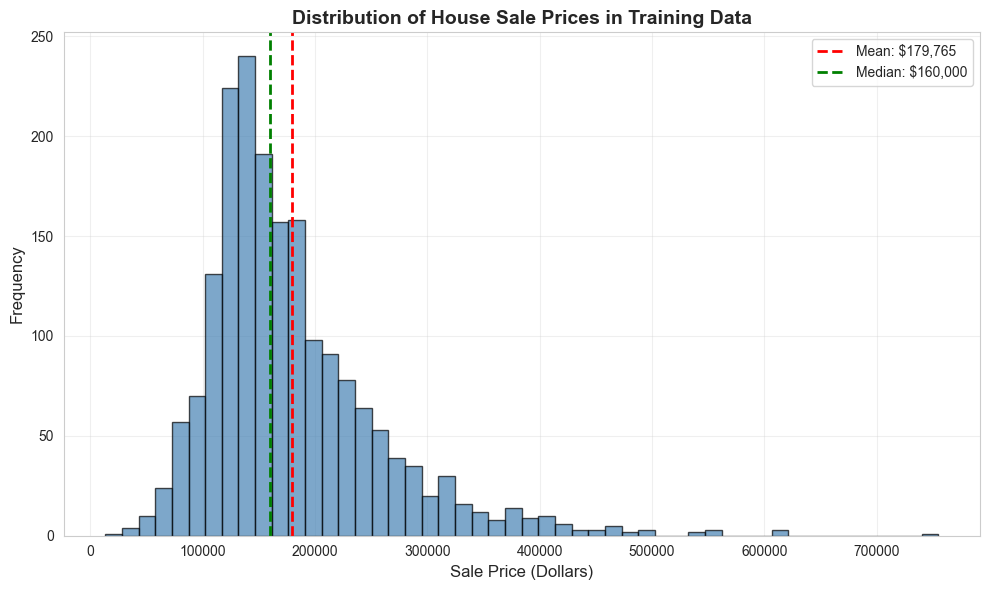

In [ ]:
#| echo: false
#| fig-cap: "Distribution of house sale prices in the training dataset"
#| fig-id: "fig-price-dist"
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(y_train, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Sale Price (Dollars)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of House Sale Prices in Training Data', fontsize=14, fontweight='bold')
ax.axvline(y_train.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${y_train.mean():,.0f}')
ax.axvline(y_train.median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${y_train.median():,.0f}')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

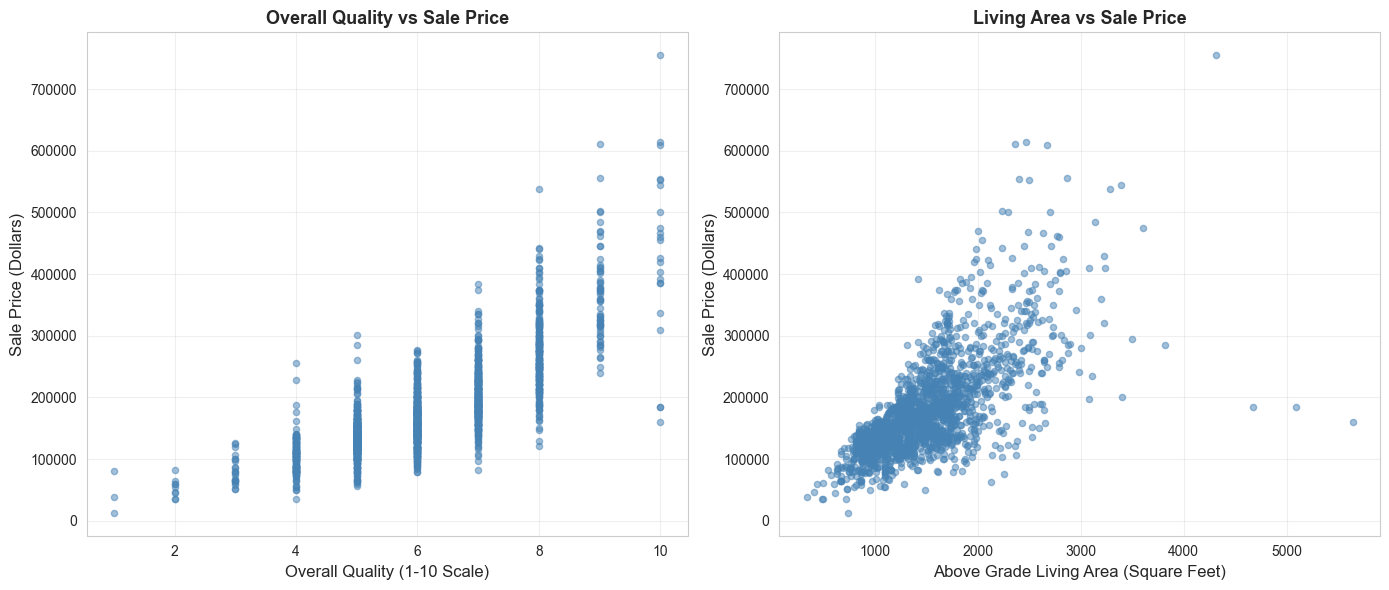

In [ ]:
#| echo: false
#| fig-cap: "Relationship between key features and sale price"
#| fig-id: "fig-feature-price"
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(X_train['Overall Qual'], y_train, alpha=0.5, s=20, color='steelblue')
ax1.set_xlabel('Overall Quality (1-10 Scale)', fontsize=12)
ax1.set_ylabel('Sale Price (Dollars)', fontsize=12)
ax1.set_title('Overall Quality vs Sale Price', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(X_train['Gr Liv Area'], y_train, alpha=0.5, s=20, color='steelblue')
ax2.set_xlabel('Above Grade Living Area (Square Feet)', fontsize=12)
ax2.set_ylabel('Sale Price (Dollars)', fontsize=12)
ax2.set_title('Living Area vs Sale Price', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Modeling

A gradient boosting regression model was selected for this prediction task. Gradient boosting is an ensemble method that combines multiple weak learners (decision trees) sequentially, with each tree correcting errors from previous trees. This approach is well-suited for regression problems with mixed data types and can capture complex non-linear relationships between features and the target variable.

The modeling pipeline consists of two main stages: preprocessing and regression. For preprocessing, numerical features are imputed using median values to handle missing data, then standardized to have zero mean and unit variance. Categorical features are imputed with a constant 'missing' value and then one-hot encoded to convert them into binary features. The `Order` and `PID` columns are excluded from the model as they are identifiers rather than predictive features.

Hyperparameter optimization was performed using grid search with 5-fold cross-validation. The search space included:

- Number of estimators: 400, 500, 600
- Learning rate: 0.05, 0.075, 0.1
- Maximum tree depth: 4, 5, 6
- Minimum samples split: 2, 5
- Minimum samples leaf: 1, 2
- Subsample ratio: 0.8, 0.82, 0.85
- Maximum features: 'sqrt', 'log2'

This resulted in 648 unique parameter combinations evaluated using cross-validation MAPE as the optimization metric. The best-performing model configuration was selected based on cross-validation performance.


In [ ]:
#| echo: false
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = [col for col in numerical_features if col not in ['Order', 'PID']]

In [30]:
#| echo: false
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')


In [ ]:
#| echo: false
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

param_grid = {
    'regressor__n_estimators': [400, 500, 600],
    'regressor__learning_rate': [0.05, 0.075, 0.1],
    'regressor__max_depth': [4, 5, 6],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__subsample': [0.8, 0.82, 0.85],
    'regressor__max_features': ['sqrt', 'log2']
}

base_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])

grid_search = GridSearchCV(
    base_model,
    param_grid,
    scoring=mape_scorer,
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_
best_params = grid_search.best_params_

In [38]:
#| echo: false
best_params = grid_search.best_params_

print(best_params)

{'regressor__learning_rate': 0.05, 'regressor__max_depth': 5, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 600, 'regressor__subsample': 0.85}


# Results

The optimized gradient boosting model achieved a test set Mean Absolute Percentage Error (MAPE) of 0.0830, which represents an average prediction error of approximately 8.3%. Additionally, 93.6% of predictions fall within 20% of the actual sale price, indicating strong predictive performance. Both metrics exceed the target thresholds of MAPE ≤ 0.085 and proportion within 20% ≥ 0.92.

The best hyperparameters selected through grid search were:

- Number of estimators: 600
- Learning rate: 0.05
- Maximum depth: 5
- Minimum samples split: 5
- Minimum samples leaf: 1
- Subsample ratio: 0.85
- Maximum features: 'sqrt'

In [32]:
#| echo: false
final_pred = model.predict(X_test)
final_mape = mean_absolute_percentage_error(y_test, final_pred)
test_prop = proportion_within_threshold(y_test, final_pred, 0.20)

In [ ]:
#| echo: false
print(f"Test Set Mean Absolute Percentage Error (MAPE): {final_mape:.4f}")
print(f"Proportion of predictions within 20% of actual: {test_prop:.4f}")

Test Set Mean Absolute Percentage Error (MAPE): 0.0830
Proportion of predictions within 20% of actual: 0.9360


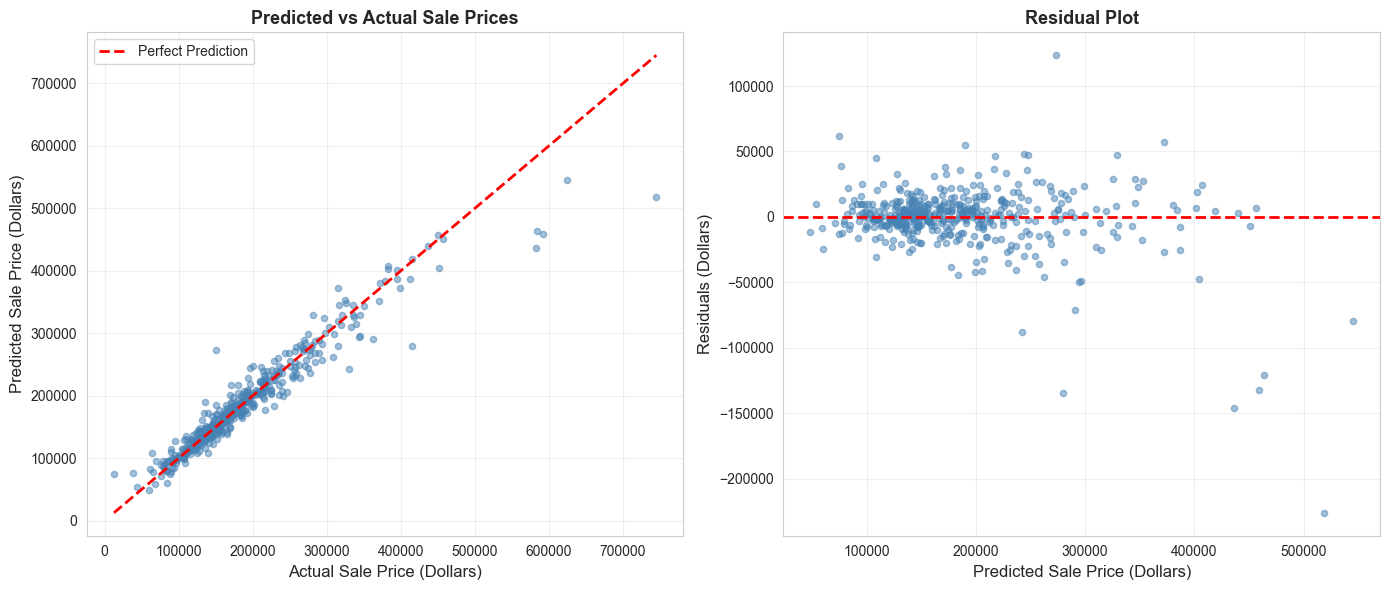

In [ ]:
#| echo: false
#| fig-cap: "Model performance visualization showing predicted versus actual sale prices (left) and residual plot (right)"
#| fig-id: "fig-predictions"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(y_test, final_pred, alpha=0.5, s=20, color='steelblue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Sale Price (Dollars)', fontsize=12)
ax1.set_ylabel('Predicted Sale Price (Dollars)', fontsize=12)
ax1.set_title('Predicted vs Actual Sale Prices', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

residuals = final_pred - y_test
ax2.scatter(final_pred, residuals, alpha=0.5, s=20, color='steelblue')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Sale Price (Dollars)', fontsize=12)
ax2.set_ylabel('Residuals (Dollars)', fontsize=12)
ax2.set_title('Residual Plot', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The scatter plot demonstrates that predictions closely follow the diagonal line representing perfect predictions, with most points clustered near the line. The residual plot shows residuals are generally centered around zero with some heteroscedasticity at higher price ranges, indicating the model performs well across most of the price distribution.


# Discussion

## Conclusion

**I would use this model in practice for house price prediction.**

The model demonstrates strong predictive performance with a test MAPE of 8.3%, meaning that on average, predictions deviate from actual sale prices by approximately 8.3%. This level of accuracy is valuable for real estate professionals who need quick price estimates. Furthermore, 93.6% of predictions fall within 20% of actual prices, which provides a reasonable confidence interval for decision-making.

## Benefits

The primary benefit of deploying this model is its ability to provide rapid, data-driven price estimates for residential properties. Real estate agents can use these predictions to help clients set competitive listing prices, while buyers can assess whether properties are fairly priced. The model's strong performance on the test set suggests it generalizes well to new data, making it suitable for production use.

The gradient boosting approach captures complex non-linear relationships between property features and sale prices that simpler linear models might miss. Features such as property size, quality ratings, and location characteristics are effectively integrated to produce accurate predictions.

## Limitations

Several limitations must be considered when using this model in practice:

1. **Temporal validity**: The model is trained on historical data and may not account for rapid market changes, economic shifts, or seasonal variations that affect real estate prices. Regular retraining with recent data would be necessary to maintain accuracy.

2. **Geographic scope**: The model's performance may vary across different geographic regions or market segments not well-represented in the training data. Care should be taken when applying predictions to properties in areas with different market dynamics.

3. **Feature availability**: The model requires all input features to be available. In practice, some features may be missing or difficult to obtain, which could affect prediction quality.

4. **Error consequences**: While the average error is 8.3%, individual predictions can have larger errors. For high-value properties, even a 10-15% error could represent tens of thousands of dollars, which could significantly impact financial decisions.

5. **Market conditions**: The model does not explicitly account for broader economic factors such as interest rates, unemployment rates, or local economic conditions that influence real estate markets.

## Recommended Usage

This model should be used as a tool to inform decision-making rather than as the sole basis for pricing decisions. It is most appropriate for:

- Initial price estimates and market analysis
- Comparative market analysis (CMA) support
- Identifying properties that may be significantly over- or under-priced
- Educational purposes for understanding property valuation factors

However, final pricing decisions should incorporate professional real estate expertise, local market knowledge, property condition assessments, and consideration of unique property features that may not be captured in the model's features.


In [35]:
#| echo: false
joblib.dump(model, "housing.joblib")

['housing.joblib']